# NLP CS60075
## Assignment-3:
## Implementing BERT from Scratch for Fake News Classification

---

**Tasks:**
1. Implement BERT from Scratch
2. Data Preprocessing: Fakeddit Dataset
3. Fine-tune BertForSequenceClassification
4. Integrated Gradients for Token Attribution

## Setup — Install / Import Dependencies

In [1]:
import math
import copy
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


---
# Task 1 — Implement BERT from Scratch
> **Hyperparameters:** `num_heads=8`, `embed_dim=512`, `num_layers=2`

### 1.1  Multi-Head Self-Attention

In [2]:
class MultiHeadSelfAttention(nn.Module):
    """
    Multi-Head Self-Attention (MHSA) as described in
    'Attention Is All You Need' (Vaswani et al.) and used in BERT.
    For each head h:
        head_h = Attention(Q W_q^h,  K W_k^h,  V W_v^h)
    where
        Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V
    All heads are concatenated and projected:
        MultiHead(Q,K,V) = Concat(head_1,...,head_H) W_o
    """

    def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert embed_dim % num_heads == 0, (
            f"embed_dim ({embed_dim}) must be divisible by num_heads ({num_heads})"
        )
        self.embed_dim  = embed_dim       # D = 512
        self.num_heads  = num_heads       # H = 8
        self.head_dim   = embed_dim // num_heads  # d_k = 64

        # Separate linear projections for Q, K, V  (each D -> D)
        self.W_q = nn.Linear(embed_dim, embed_dim)   # maps to H * d_k
        self.W_k = nn.Linear(embed_dim, embed_dim)
        self.W_v = nn.Linear(embed_dim, embed_dim)
        # Output projection  (H * d_v -> D)
        self.W_o = nn.Linear(embed_dim, embed_dim)

        self.attn_dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(self.head_dim)  # sqrt(d_k)

    def split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """Reshape (B, L, D) -> (B, H, L, d_k)"""
        B, L, D = x.size()
        x = x.view(B, L, self.num_heads, self.head_dim)  # (B, L, H, d_k)
        return x.transpose(1, 2)                          # (B, H, L, d_k)

    def forward(
        self,
        x: torch.Tensor,
        attention_mask: torch.Tensor = None,
    ):
        """
        Args:
            x               : (B, L, D)  — input token embeddings (Q = K = V for self-attn)
            attention_mask  : (B, L)  boolean/float mask; 1 = attend, 0 = ignore
        Returns:
            output          : (B, L, D)
            attn_weights    : (B, H, L, L)  for inspection
        """
        B, L, D = x.size()

        # ── Linear projections ──────────────────────────────────────────────
        Q = self.W_q(x)   # (B, L, D)
        K = self.W_k(x)   # (B, L, D)
        V = self.W_v(x)   # (B, L, D)

        # ── Split into H heads ───────────────────────────────────────────────
        Q = self.split_heads(Q)   # (B, H, L, d_k)
        K = self.split_heads(K)   # (B, H, L, d_k)
        V = self.split_heads(V)   # (B, H, L, d_k)

        # ── Scaled Dot-Product Attention ─────────────────────────────────────
        # scores: (B, H, L, L)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        # Apply attention mask, set padding positions to -inf before softmax
        if attention_mask is not None:
            # attention_mask: (B, L) -> (B, 1, 1, L)  for broadcasting over heads & queries
            mask = attention_mask.unsqueeze(1).unsqueeze(2)  # (B, 1, 1, L)
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn_weights = F.softmax(scores, dim=-1)   # (B, H, L, L)
        attn_weights = self.attn_dropout(attn_weights)

        # ── Weighted sum of V ────────────────────────────────────────────────
        context = torch.matmul(attn_weights, V)    # (B, H, L, d_k)

        # ── Concatenate heads ────────────────────────────────────────────────
        context = context.transpose(1, 2).contiguous()   # (B, L, H, d_k)
        context = context.view(B, L, D)                  # (B, L, D)

        # ── Final output projection ──────────────────────────────────────────
        output = self.W_o(context)                       # (B, L, D)

        return output, attn_weights


print("MultiHeadSelfAttention defined")

MultiHeadSelfAttention defined


### 1.2  Position-wise Feed-Forward Layer

In [3]:
class FeedForwardLayer(nn.Module):
    """
    Position-wise Feed-Forward Network (FFN):
        FFN(x) = GELU(x W_1 + b_1) W_2 + b_2
    """

    def __init__(self, embed_dim: int, ff_dim: int = None, dropout: float = 0.1):
        super().__init__()
        ff_dim = ff_dim or 4 * embed_dim   # BERT default: 4 * 512 = 2048
        self.fc1     = nn.Linear(embed_dim, ff_dim)
        self.fc2     = nn.Linear(ff_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def gelu(self, x: torch.Tensor) -> torch.Tensor:
        """Gaussian Error Linear Unit: same approximation used in original BERT."""
        return x * 0.5 * (1.0 + torch.tanh(
            math.sqrt(2.0 / math.pi) * (x + 0.044715 * x.pow(3))
        ))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x : (B, L, D)
        Returns:
            x : (B, L, D)
        """
        x = self.fc1(x)      # (B, L, ff_dim)
        x = self.gelu(x)     # (B, L, ff_dim)
        x = self.dropout(x)
        x = self.fc2(x)      # (B, L, D)
        return x


print("FeedForwardLayer defined")

FeedForwardLayer defined


### 1.3  Transformer Encoder Layer

In [4]:
class TransformerEncoderLayer(nn.Module):
    """
    A single BERT Transformer Encoder Layer:
        1. Multi-Head Self-Attention  + residual + LayerNorm
        2. Feed-Forward Network       + residual + LayerNorm

    Post-LN variant: LayerNorm is applied AFTER residual addition.
    """

    def __init__(
        self,
        embed_dim: int,
        num_heads: int,
        ff_dim: int = None,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.attention  = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.ffn        = FeedForwardLayer(embed_dim, ff_dim, dropout)

        self.norm1      = nn.LayerNorm(embed_dim, eps=1e-12)
        self.norm2      = nn.LayerNorm(embed_dim, eps=1e-12)

        self.dropout1   = nn.Dropout(dropout)
        self.dropout2   = nn.Dropout(dropout)

    def forward(
        self,
        x: torch.Tensor,
        attention_mask: torch.Tensor = None,
    ):
        """
        Args:
            x              : (B, L, D)  input to this encoder layer
            attention_mask : (B, L)     1 = real token, 0 = padding
        Returns:
            x              : (B, L, D)  final output of this encoder layer
            attn_weights   : (B, H, L, L)
            attn_out_raw   : (B, L, D)  output of MHSA sub-layer (pre-residual)
            attn_out_post  : (B, L, D)  output of MHSA sub-layer (after residual+LN)
            ffn_out_raw    : (B, L, D)  output of FFN sub-layer (pre-residual)
            ffn_out_final  : (B, L, D)  output of FFN sub-layer (after residual+LN) == x
        """
        # ── Sub-layer 1: Multi-Head Self-Attention ───────────────────────────
        attn_out_raw, attn_weights = self.attention(x, attention_mask)   # (B, L, D)
        attn_out_post = self.norm1(x + self.dropout1(attn_out_raw))      # residual + LN

        # ── Sub-layer 2: Feed-Forward Network ───────────────────────────────

        ffn_intermediate = self.ffn(attn_out_post)                                      # (B, L, D)  raw FFN output
        ffn_out_final    = self.norm2(attn_out_post + self.dropout2(ffn_intermediate))  # residual + LN

        return ffn_out_final, attn_weights, attn_out_raw, attn_out_post, ffn_intermediate, ffn_out_final


print("TransformerEncoderLayer defined")


TransformerEncoderLayer defined


### 1.4  Full BERT Model (Embeddings + Encoder Stack + Pooler + Classifier)

In [5]:
class BERTEmbeddings(nn.Module):
    """
    BERT Input Representation:
        E = TokenEmbedding + PositionalEmbedding + SegmentEmbedding
    followed by LayerNorm + Dropout.

    Token embeddings     : vocab_size  -> embed_dim
    Positional embeddings: max_seq_len -> embed_dim
    Segment embeddings   : 2           -> embed_dim  (sentence A vs B)
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        max_seq_len: int = 512,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.token_embedding    = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.position_embedding = nn.Embedding(max_seq_len, embed_dim)        # learned
        self.segment_embedding  = nn.Embedding(2, embed_dim)                  # 0=A, 1=B

        self.layer_norm = nn.LayerNorm(embed_dim, eps=1e-12)
        self.dropout    = nn.Dropout(dropout)

    def forward(
        self,
        input_ids: torch.Tensor,
        token_type_ids: torch.Tensor = None,
    ) -> torch.Tensor:
        """
        Args:
            input_ids     : (B, L)  token indices
            token_type_ids: (B, L)  0 or 1; defaults to all-zero
        Returns:
            embeddings    : (B, L, D)  combined + normed
            tok_emb       : (B, L, D)  raw token embeddings
            pos_emb       : (1, L, D)  raw positional embeddings
            seg_emb       : (B, L, D)  raw segment embeddings
        """
        B, L = input_ids.size()

        if token_type_ids is None:
            token_type_ids = torch.zeros_like(input_ids)  # all sentence A

        positions = torch.arange(L, device=input_ids.device).unsqueeze(0)  # (1, L)

        tok_emb = self.token_embedding(input_ids)        # (B, L, D)
        pos_emb = self.position_embedding(positions)     # (1, L, D) broadcasts
        seg_emb = self.segment_embedding(token_type_ids) # (B, L, D)

        embeddings = tok_emb + pos_emb + seg_emb
        embeddings = self.layer_norm(embeddings)
        embeddings = self.dropout(embeddings)
        return embeddings, tok_emb, pos_emb, seg_emb   # return individual parts for inspection


class BERTPooler(nn.Module):
    """
    BERT Pooler: takes the [CLS] token hidden state (first token)
    and passes it through a dense layer with tanh activation.
    Used for sentence-level classification.
    """

    def __init__(self, embed_dim: int):
        super().__init__()
        self.dense = nn.Linear(embed_dim, embed_dim)

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        """
        Args:
            hidden_states : (B, L, D)  encoder output
        Returns:
            pooled        : (B, D)     [CLS] representation
        """
        cls_token_state = hidden_states[:, 0, :]      # (B, D) first token = [CLS]
        pooled = torch.tanh(self.dense(cls_token_state))
        return pooled


class BertModel(nn.Module):
    """
    Complete BERT model built from scratch:
        Input IDs
            ↓
        BERTEmbeddings  (Token + Positional + Segment)
            ↓
        N × TransformerEncoderLayer
            ↓
        BERTPooler  ([CLS] token)
            ↓
        Dropout + Linear Classifier Head
            ↓
        Logits  (num_classes)

    Hyperparameters used:
        embed_dim  = 512
        num_heads  = 8
        num_layers = 2
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int   = 512,
        num_heads: int   = 8,
        num_layers: int  = 2,
        ff_dim: int      = None,       # defaults to 4 * embed_dim
        max_seq_len: int = 512,
        num_classes: int = 2,
        dropout: float   = 0.1,
    ):
        super().__init__()
        self.embeddings = BERTEmbeddings(vocab_size, embed_dim, max_seq_len, dropout)

        self.encoder_layers = nn.ModuleList([
            TransformerEncoderLayer(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

        self.pooler     = BERTPooler(embed_dim)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor  = None,
        token_type_ids: torch.Tensor  = None,
        return_intermediates: bool    = False,
    ):
        """
        Args:
            input_ids           : (B, L)
            attention_mask      : (B, L)  1=real, 0=pad
            token_type_ids      : (B, L)  0=sent-A, 1=sent-B
            return_intermediates: if True, also return a dict of intermediate shapes
        Returns:
            logits              : (B, num_classes)
            [intermediates]     : dict of tensors for shape inspection
        """
        # ── Embedding layer ──────────────────────────────────────────────────
        embeddings, tok_emb, pos_emb, seg_emb = self.embeddings(input_ids, token_type_ids)
        # embeddings: (B, L, D)

        # ── Transformer Encoder Stack ────────────────────────────────────────
        hidden = embeddings
        all_attn_weights  = []
        all_attn_raw  = []
        all_attn_post  = []   # output of MHSA sub-layer (after residual+LN)
        all_ffn_raw  = []
        all_ffn_post   = []   # output of FFN sub-layer (after residual+LN)

        for layer in self.encoder_layers:
            hidden, attn_w, attn_out_raw, attn_out_post, ffn_out_raw, ffn_out_post = layer(hidden, attention_mask)
            all_attn_weights.append(attn_w)
            all_attn_raw.append(attn_out_raw)
            all_attn_post.append(attn_out_post)
            all_ffn_raw.append(ffn_out_raw)
            all_ffn_post.append(ffn_out_post)

        # ── Pooler (uses last encoder output) ───────────────────────────────
        pooled = self.pooler(hidden)          # (B, D)

        # ── Classifier head ──────────────────────────────────────────────────
        pooled  = self.dropout(pooled)
        logits  = self.classifier(pooled)     # (B, num_classes)
        probs   = F.softmax(logits, dim=-1)   # (B, num_classes)

        if return_intermediates:
            intermediates = {
                'token_embeddings':      tok_emb,
                'positional_embeddings': pos_emb,
                'segment_embeddings':    seg_emb,
                'combined_embeddings':   embeddings,
                'attn_weights':          all_attn_weights,
                'attn_raw_outputs':      all_attn_raw,
                'attn_post_outputs':     all_attn_post,   #  MHSA output per layer
                'ffn_raw_outputs':       all_ffn_raw,
                'ffn_post_outputs':      all_ffn_post,    #  FFN output per layer
                'encoder_layer_outputs': all_ffn_post,    # all layers
                'encoder_output':        hidden,          # final encoder output = last hidden state
                'pooler_output':         pooled,
                'logits':                logits,
                'probabilities':         probs,
            }
            return logits, probs, intermediates

        return logits, probs


print("BERTEmbeddings, BERTPooler, BertModel defined")


BERTEmbeddings, BERTPooler, BertModel defined


### 1.5  Tokenize a Sample Sentence and Inspect Embedding Shapes

In [2]:
# ── Load bert-base-uncased tokenizer ────────────────────────────────────────
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


In [7]:
SAMPLE_SENTENCE = (
    "Scientists have discovered a new species of deep-sea fish that can survive in extreme pressure and darkness."
)
print(f"Sample sentence:\n  {SAMPLE_SENTENCE}\n")

# Tokenize
encoding = tokenizer(
    SAMPLE_SENTENCE,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=64,
)

input_ids      = encoding['input_ids']       # (1, L)
attention_mask = encoding['attention_mask']  # (1, L)
# Segment IDs = all zeros (as required by the assignment)
token_type_ids = torch.zeros_like(input_ids)

tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())
print(f"Tokens ({len(tokens)}):")
print(tokens)
print(f"\ninput_ids shape     : {input_ids.shape}")
print(f"attention_mask shape: {attention_mask.shape}")
print(f"token_type_ids shape: {token_type_ids.shape}")

Sample sentence:
  Scientists have discovered a new species of deep-sea fish that can survive in extreme pressure and darkness.

Tokens (22):
['[CLS]', 'scientists', 'have', 'discovered', 'a', 'new', 'species', 'of', 'deep', '-', 'sea', 'fish', 'that', 'can', 'survive', 'in', 'extreme', 'pressure', 'and', 'darkness', '.', '[SEP]']

input_ids shape     : torch.Size([1, 22])
attention_mask shape: torch.Size([1, 22])
token_type_ids shape: torch.Size([1, 22])


In [8]:
# ── Instantiate scratch BERT ─────────────────────────────────────────────────
VOCAB_SIZE  = tokenizer.vocab_size   # bert-base-uncased 30522
EMBED_DIM   = 512
NUM_HEADS   = 8
NUM_LAYERS  = 2
NUM_CLASSES = 2

model = BertModel(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = EMBED_DIM,
    num_heads   = NUM_HEADS,
    num_layers  = NUM_LAYERS,
    num_classes = NUM_CLASSES,
).to(DEVICE)

model.eval()

input_ids_d      = input_ids.to(DEVICE)
attention_mask_d = attention_mask.to(DEVICE)
token_type_ids_d = token_type_ids.to(DEVICE)

with torch.no_grad():
    logits, probs, intermediates = model(
        input_ids_d,
        attention_mask_d,
        token_type_ids_d,
        return_intermediates=True,
    )

print("Forward pass done")

Forward pass done


In [9]:
# ── Shape Report ─────────────────────────────────────────────────────────────
print("=" * 70)
print(" EMBEDDING AND LAYER SHAPES for TASK 1 SHAPE REPORT")
print("=" * 70)

tok     = intermediates['token_embeddings']
pos     = intermediates['positional_embeddings']
seg     = intermediates['segment_embeddings']
comb    = intermediates['combined_embeddings']
attn_outs_raw  = intermediates['attn_raw_outputs']
attn_outs_post = intermediates['attn_post_outputs']   # MHSA output per layer (post-LN)
ffn_outs_raw   = intermediates['ffn_raw_outputs']
ffn_outs_post = intermediates['ffn_post_outputs']    # FFN output per layer(post-LN)
logit_t    = intermediates['logits']
prob_t     = intermediates['probabilities']

print(f"\n{'Component':<50} {'Shape'}")
print("-" * 70)
print(f"{'Token Embeddings':<50} {str(tuple(tok.shape))}")
print(f"{'Positional Embeddings':<50} {str(tuple(pos.shape))}")
print(f"{'Segment Embeddings':<50} {str(tuple(seg.shape))}")
print(f"{'Combined Embeddings (input to encoder)':<50} {str(tuple(comb.shape))}")

for i, (attn_w_layer, attn_out_raw_layer, attn_out_post_layer, ffn_raw_layer, ffn_post_layer) in enumerate(
        zip(intermediates['attn_weights'], attn_outs_raw, attn_outs_post, ffn_outs_raw, ffn_outs_post)):
    print(f"  Encoder Layer {i+1} — Attention weights                                 {str(tuple(attn_w_layer.shape))}")
    # MHSA output (pre-residual), shape (B, L, D)
    print(f"  Encoder Layer {i+1} — MHSA output (pre-residual)                        {str(tuple(attn_out_raw_layer.shape))}")
    # attn_outs_post = output AFTER MHSA sub-layer (residual + LayerNorm), shape (B, L, D)
    print(f"  Encoder Layer {i+1} — MHSA output (after residual + LayerNorm)          {str(tuple(attn_out_post_layer.shape))}")
    #  FFN output (pre-residual), shape (B, L, D)
    print(f"  Encoder Layer {i+1} — FFN output  (pre-residual)                        {str(tuple(ffn_raw_layer.shape))}")
    # ffn_outs_post = output AFTER FFN sub-layer (residual + LayerNorm), shape (B, L, D)
    print(f"  Encoder Layer {i+1} — FFN output  (after residual + LayerNorm)          {str(tuple(ffn_post_layer.shape))}")

print(f"{'Logits':<50} {str(tuple(logit_t.shape))}")
print(f"{'Output Probabilities':<50} {str(tuple(prob_t.shape))}")
print()
print(f"Predicted class: {prob_t.argmax(dim=-1).item()}  (0=non-fake, 1=fake)")
print(f"Class probabilities: {prob_t.squeeze().tolist()}")

# ── Parameter Shape Table ─────────────────────────────────────────────────────
print("\n" + "=" * 100)
print(" MODEL PARAMETER SHAPES (Task 1 requirement)")
print("=" * 100)
print(f"  {'Parameter Name':<65} {'Shape':<25} {'# Params':>12}")
print("-" * 100)
total = 0
for name, param in model.named_parameters():
    shape = tuple(param.shape)
    count = param.numel()
    total += count
    print(f"  {name:<65} {str(shape):<25} {count:>12,}")
print("-" * 100)
print(f"  {'TOTAL TRAINABLE PARAMETERS':<65} {'':25} {total:>12,}")
print("=" * 100)

 EMBEDDING AND LAYER SHAPES for TASK 1 SHAPE REPORT

Component                                          Shape
----------------------------------------------------------------------
Token Embeddings                                   (1, 22, 512)
Positional Embeddings                              (1, 22, 512)
Segment Embeddings                                 (1, 22, 512)
Combined Embeddings (input to encoder)             (1, 22, 512)
  Encoder Layer 1 — Attention weights                                 (1, 8, 22, 22)
  Encoder Layer 1 — MHSA output (pre-residual)                        (1, 22, 512)
  Encoder Layer 1 — MHSA output (after residual + LayerNorm)          (1, 22, 512)
  Encoder Layer 1 — FFN output  (pre-residual)                        (1, 22, 512)
  Encoder Layer 1 — FFN output  (after residual + LayerNorm)          (1, 22, 512)
  Encoder Layer 2 — Attention weights                                 (1, 8, 22, 22)
  Encoder Layer 2 — MHSA output (pre-residual)               

---
# Task 2 — Data Preprocessing (Fakeddit Dataset)

> **Dataset:** Fakeddit — `all_train.tsv`, `all_test_public.tsv`, `all_validate.tsv`  
> Downloaded from: https://github.com/entitize/Fakeddit  

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = "/content/drive/MyDrive/NLP/Fakeddit"   # directory containing the three .tsv files
TRAIN_FILE = os.path.join(DATA_DIR, "all_train.tsv")
TEST_FILE  = os.path.join(DATA_DIR, "all_test_public.tsv")
VAL_FILE   = os.path.join(DATA_DIR, "all_validate.tsv")

SAMPLES_PER_CLASS = 2500
REQUIRED_COLS     = ['id', 'clean_title', '2_way_label']


def load_fakeddit_split(filepath: str) -> pd.DataFrame:
    """Load one Fakeddit .tsv split and keep only the required columns."""
    df = pd.read_csv(filepath, sep='\t', low_memory=False)

    col_map = {}
    for col in df.columns:
        if col.strip().lower().replace(' ', '_') == 'clean_title':
            col_map[col] = 'clean_title'
        elif col.strip().lower().replace(' ', '_') == '2_way_label':
            col_map[col] = '2_way_label'
        elif col.strip().lower() == 'id':
            col_map[col] = 'id'
    df = df.rename(columns=col_map)
    available = [c for c in REQUIRED_COLS if c in df.columns]
    return df[available].copy()


# ── Load & Combine ────────────────────────────────────────────────────────────
try:
    df_train = load_fakeddit_split(TRAIN_FILE)
    df_test  = load_fakeddit_split(TEST_FILE)
    df_val   = load_fakeddit_split(VAL_FILE)
    df_all   = pd.concat([df_train, df_test, df_val], ignore_index=True)

except FileNotFoundError:
    print("Fakeddit .tsv files not found.")

print(f"Total posts in combined dataset (before cleaning): {len(df_all):,}")
print(f"\nLabel distribution (before balancing):")
print(df_all['2_way_label'].value_counts().to_string())


Total posts in combined dataset (before cleaning): 1,063,106

Label distribution (before balancing):
2_way_label
0    578189
1    484917


In [4]:
# ── Step 1: Clean — drop nulls in required columns ───────────────────────────
n_before_clean = len(df_all)
df_all.dropna(subset=['clean_title', '2_way_label'], inplace=True)
df_all['2_way_label'] = df_all['2_way_label'].astype(int)
n_after_clean = len(df_all)
print(f"Rows before cleaning : {n_before_clean:,}")
print(f"Rows dropped (NaN)   : {n_before_clean - n_after_clean:,}")
print(f"Rows after  cleaning : {n_after_clean:,}  ← this is the 'original dataset' count reported below")

# ── Step 2: Balance Dataset ───────────────────────────────────────────────────
df_fake    = df_all[df_all['2_way_label'] == 1].sample(n=SAMPLES_PER_CLASS, random_state=SEED)
df_nonfake = df_all[df_all['2_way_label'] == 0].sample(n=SAMPLES_PER_CLASS, random_state=SEED)
df_balanced = pd.concat([df_fake, df_nonfake]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nBalanced dataset size: {len(df_balanced):,}")
print(f"  Fake posts   (label=1): {(df_balanced['2_way_label']==1).sum():,}")
print(f"  Non-fake posts (label=0): {(df_balanced['2_way_label']==0).sum():,}")

# ── Step 3: Train-Test Split (80/20, stratified) ─────────────────────────────
df_tr, df_te = train_test_split(
    df_balanced,
    test_size=0.20,
    random_state=SEED,
    stratify=df_balanced['2_way_label'],
)
df_tr = df_tr.reset_index(drop=True)
df_te = df_te.reset_index(drop=True)

# ── Step 4: Report Statistics ─────────────────────────────────────────────────
# 'Original combined posts' refers to the number of rows AFTER dropping
#  nulls in clean_title / 2_way_label. The raw concatenated file has {n_before_clean:,} rows;

print("\n" + "=" * 55)
print(" DATASET STATISTICS — TASK 2")
print("=" * 55)
print(f"  Raw combined posts (before cleaning): {n_before_clean:>8,}")
print(f"  Rows dropped (missing title/label):   {n_before_clean - n_after_clean:>8,}")
print(f"  Original combined posts (after clean):{n_after_clean:>8,}")
print(f"  Balanced dataset total:               {len(df_balanced):>8,}")
print(f"    Fake posts (label=1):                {(df_balanced['2_way_label']==1).sum():>8,}")
print(f"    Non-fake posts (label=0):            {(df_balanced['2_way_label']==0).sum():>8,}")
print(f"  Train set:                            {len(df_tr):>8,}")
print(f"    Train fake:                          {(df_tr['2_way_label']==1).sum():>8,}")
print(f"    Train non-fake:                      {(df_tr['2_way_label']==0).sum():>8,}")
print(f"  Test set:                             {len(df_te):>8,}")
print(f"    Test fake:                           {(df_te['2_way_label']==1).sum():>8,}")
print(f"    Test non-fake:                       {(df_te['2_way_label']==0).sum():>8,}")

Rows before cleaning : 1,063,106
Rows dropped (NaN)   : 91,300
Rows after  cleaning : 971,806  ← this is the 'original dataset' count reported below

Balanced dataset size: 5,000
  Fake posts   (label=1): 2,500
  Non-fake posts (label=0): 2,500

 DATASET STATISTICS — TASK 2
  Raw combined posts (before cleaning): 1,063,106
  Rows dropped (missing title/label):     91,300
  Original combined posts (after clean): 971,806
  Balanced dataset total:                  5,000
    Fake posts (label=1):                   2,500
    Non-fake posts (label=0):               2,500
  Train set:                               4,000
    Train fake:                             2,000
    Train non-fake:                         2,000
  Test set:                                1,000
    Test fake:                                500
    Test non-fake:                            500


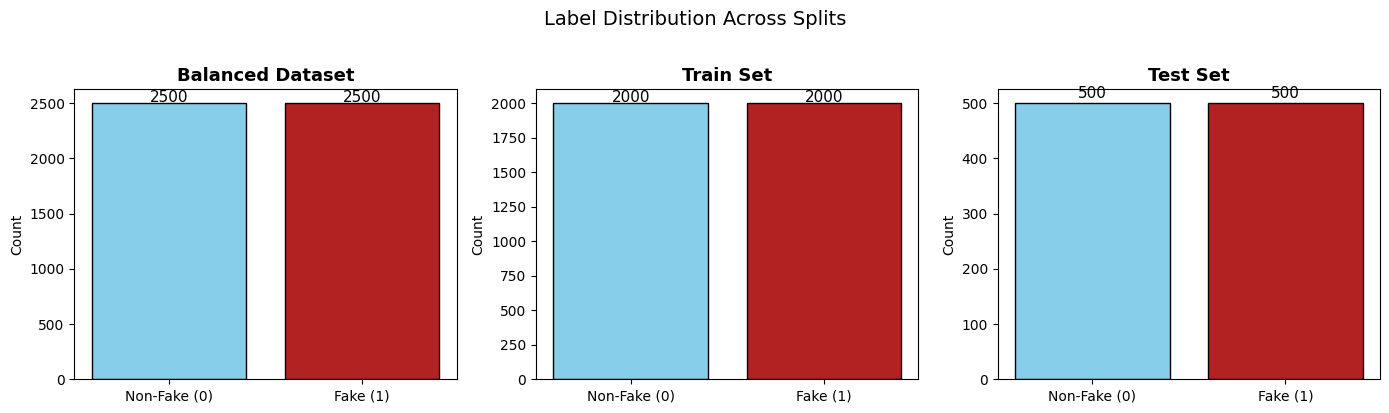

Saved: label_distribution.png


In [13]:
# ── Visualize distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (df_sub, title) in zip(axes, [
    (df_balanced, 'Balanced Dataset'),
    (df_tr,       'Train Set'),
    (df_te,       'Test Set'),
]):
    counts = df_sub['2_way_label'].value_counts().sort_index()
    ax.bar(['Non-Fake (0)', 'Fake (1)'], counts.values, color=['skyblue', 'firebrick'], edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, str(v), ha='center', fontsize=11)
plt.suptitle('Label Distribution Across Splits', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('label_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: label_distribution.png")

---
# Task 3 — Fine-tune BertForSequenceClassification & Report Metrics

In [14]:
# ── PyTorch Dataset ───────────────────────────────────────────────────────────
class FakedditDataset(Dataset):
    """
    PyTorch Dataset wrapper for the Fakeddit splits.
    """

    MAX_LEN = 128

    def __init__(self, df: pd.DataFrame, tokenizer: BertTokenizer):
        self.texts     = df['clean_title'].astype(str).tolist()
        self.labels    = df['2_way_label'].tolist()
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.MAX_LEN,
            truncation=True,
            padding='max_length',
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': enc['token_type_ids'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
        }


# ── Hyperparameters ───────────────────────────────────────────────────────────
EPOCHS        = 3
BATCH_SIZE    = 16
LR            = 2e-5
WEIGHT_DECAY  = 0.01       # L2 regularisation (applied to weights, not biases/LayerNorm)
CLASSIFIER_DROPOUT = 0.3
WARMUP_FRAC   = 0.1
MAX_LEN       = FakedditDataset.MAX_LEN

print("Hyperparameters:")
print(f"  Model              : bert-base-uncased (BertForSequenceClassification)")
print(f"  Epochs (max)       : {EPOCHS}")
print(f"  Batch size         : {BATCH_SIZE}")
print(f"  Learning rate      : {LR}")
print(f"  Weight decay       : {WEIGHT_DECAY}  (L2 regularisation on weight params)")
print(f"  Classifier dropout : {CLASSIFIER_DROPOUT}")
print(f"  Optimizer          : AdamW ")
print(f"  Scheduler          : Linear warm-up + linear decay")
print(f"  Max seq len        : {MAX_LEN} tokens (truncation: first {MAX_LEN} tokens retained)")
print(f"  Loss function      : CrossEntropyLoss")
print(f"  Device             : {DEVICE}")


Hyperparameters:
  Model              : bert-base-uncased (BertForSequenceClassification)
  Epochs (max)       : 3
  Batch size         : 16
  Learning rate      : 2e-05
  Weight decay       : 0.01  (L2 regularisation on weight params)
  Classifier dropout : 0.3
  Optimizer          : AdamW 
  Scheduler          : Linear warm-up + linear decay
  Max seq len        : 128 tokens (truncation: first 128 tokens retained)
  Loss function      : CrossEntropyLoss
  Device             : cuda


In [15]:
# ── Datasets & Loaders ───────────────────────────────────────────────────────
train_ds = FakedditDataset(df_tr, tokenizer)
test_ds  = FakedditDataset(df_te, tokenizer)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nTrain batches: {len(train_loader)} | Test batches: {len(test_loader)}")


Train batches: 250 | Test batches: 63


In [16]:
# ── Load pre-trained BertForSequenceClassification ──────────────────────────
bert_clf = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,
    classifier_dropout=CLASSIFIER_DROPOUT,
)
bert_clf = bert_clf.to(DEVICE)



config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
# ── Optimizer.. exclude biases and LayerNorm params from weight decay ─────────
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_params = [
    {
        'params': [p for n, p in bert_clf.named_parameters()
                   if not any(nd in n for nd in no_decay)],
        'weight_decay': WEIGHT_DECAY,
    },
    {
        'params': [p for n, p in bert_clf.named_parameters()
                   if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0,
    },
]
optimizer = AdamW(optimizer_grouped_params, lr=LR, eps=1e-8)

# ── Scheduler ────────────────────────────────────────────────────────────────
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(WARMUP_FRAC * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps,
)

criterion = nn.CrossEntropyLoss()

print(f"Total training steps : {total_steps}")
print(f"Warm-up steps        : {warmup_steps}")
print(f"Weight-decayed params: {sum(p.numel() for g in optimizer_grouped_params[:1] for p in g['params']):,}")
print(f"Non-decayed params   : {sum(p.numel() for g in optimizer_grouped_params[1:] for p in g['params']):,}")

Total training steps : 750
Warm-up steps        : 75
Weight-decayed params: 109,361,664
Non-decayed params   : 122,114


In [18]:
# Training
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for step, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids      = input_ids,
            attention_mask = attention_mask,
            token_type_ids = token_type_ids,
            labels = labels,
        )
        logits = outputs.logits                          # (B, 2)
        loss   = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        preds       = logits.argmax(dim=-1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if (step + 1) % 50 == 0:
            print(f"   Step {step+1}/{len(loader)}  loss={loss.item():.4f}")

    return total_loss / len(loader), correct / total

# ── Training loop ────────────────────────────────
history = {'train_loss': [], 'train_acc': []}

for epoch in range(1, EPOCHS + 1):
    print(f"\n── Epoch {epoch}/{EPOCHS} ──────────────────────────────────")
    tr_loss, tr_acc = train_epoch(bert_clf, train_loader, optimizer, scheduler, criterion, DEVICE)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)

    print(f"  Train loss: {tr_loss:.4f} | Train acc: {tr_acc:.4f}")



── Epoch 1/3 ──────────────────────────────────
   Step 50/250  loss=0.6408
   Step 100/250  loss=0.3174
   Step 150/250  loss=0.5232
   Step 200/250  loss=0.3250
   Step 250/250  loss=0.3392
  Train loss: 0.5431 | Train acc: 0.7322

── Epoch 2/3 ──────────────────────────────────
   Step 50/250  loss=0.2730
   Step 100/250  loss=0.1947
   Step 150/250  loss=0.2085
   Step 200/250  loss=0.3622
   Step 250/250  loss=0.2517
  Train loss: 0.3622 | Train acc: 0.8515

── Epoch 3/3 ──────────────────────────────────
   Step 50/250  loss=0.1715
   Step 100/250  loss=0.0613
   Step 150/250  loss=0.0514
   Step 200/250  loss=0.2802
   Step 250/250  loss=0.1030
  Train loss: 0.2334 | Train acc: 0.9125


In [ ]:
bert_clf.save_pretrained('bert_finetuned')
tokenizer.save_pretrained("bert_finetuned")
print("Model saved to bert_finetuned/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to bert_finetuned/


In [20]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                token_type_ids = token_type_ids,
            )

            logits = outputs.logits
            loss   = criterion(logits, labels)
            total_loss += loss.item()

            preds = logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), np.array(all_preds), np.array(all_labels)


In [21]:
# ── Evaluation on Test Set ─────────────────────────────────────────────
_, y_pred, y_true = evaluate(bert_clf, test_loader, criterion, DEVICE)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec  = recall_score(y_true, y_pred,    average='weighted')
f1   = f1_score(y_true, y_pred,        average='weighted')
cm   = confusion_matrix(y_true, y_pred)

print("\n" + "=" * 60)
print(" TEST SET METRICS for TASK 3")
print("=" * 60)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print()
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Non-Fake', 'Fake']))



 TEST SET METRICS for TASK 3
  Accuracy  : 0.7910
  Precision : 0.7928
  Recall    : 0.7910
  F1-Score  : 0.7907


Classification Report:
              precision    recall  f1-score   support

    Non-Fake       0.82      0.75      0.78       500
        Fake       0.77      0.83      0.80       500

    accuracy                           0.79      1000
   macro avg       0.79      0.79      0.79      1000
weighted avg       0.79      0.79      0.79      1000



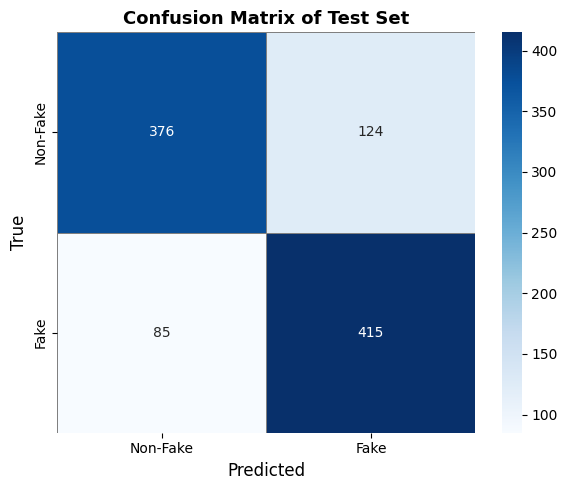

Saved: confusion_matrix.png


In [22]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Non-Fake', 'Fake'],
    yticklabels=['Non-Fake', 'Fake'],
    ax=ax, linewidths=0.5, linecolor='grey',
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True',      fontsize=12)
ax.set_title('Confusion Matrix of Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

---
# Task 4 — Integrated Gradients for Token Attribution

In [5]:
!pip install captum

In [6]:
from transformers import BertForSequenceClassification
bert_clf = BertForSequenceClassification.from_pretrained('bert_finetuned')
bert_clf = bert_clf.to(DEVICE)
bert_clf.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [7]:
from captum.attr import LayerIntegratedGradients

# ── Ensure model is in eval mode ─────────────────────────────────────────────
# bert_clf.eval()

# ── Forward function for Captum ──────────────────────────────────────────────
def forward_for_ig(combined_embeds, attention_mask, token_type_ids):
    """
    Captum calls this function with the (interpolated) OUTPUT of the hooked
    layer — bert.embeddings. That output IS the full combined embedding
    (word + position + segment + LayerNorm), so we pass it directly to the
    encoder via inputs_embeds.

    We must NOT call bert.embeddings again inside here, because Captum hooks
    into its output; calling it again would create a second, unhooked path.
    """
    outputs = bert_clf(
        inputs_embeds  = combined_embeds,
        attention_mask = attention_mask,
        token_type_ids = token_type_ids,
    )
    return outputs.logits   # (B, num_classes)


# ── Hook on bert.embeddings (the full embedding module) ──────────────────────
embedding_layer = bert_clf.bert.embeddings

lig = LayerIntegratedGradients(forward_for_ig, embedding_layer)

print("LayerIntegratedGradients initialised")

LayerIntegratedGradients initialised


In [13]:
def compute_attributions(text: str, target_class: int, n_steps: int):
    """
    Compute Layer Integrated Gradients for `text` w.r.t. `target_class`.
    n_steps should give convergence delta well below 0.05.
    internal_batch_size=20 processes 20 interpolation steps at a time
    """
    enc = tokenizer(
        text,
        max_length=MAX_LEN,
        truncation=True,
        padding='max_length',
        return_tensors='pt',
    )

    input_ids      = enc['input_ids'].to(DEVICE) # Move to device
    attention_mask = enc['attention_mask'].to(DEVICE) # Move to device
    token_type_ids = enc['token_type_ids'].to(DEVICE) # Move to device

    # Trim to actual (non-padding) token length to reduce VRAM usage
    actual_len     = attention_mask.sum().item()
    input_ids      = input_ids[:, :actual_len]
    attention_mask = attention_mask[:, :actual_len]
    token_type_ids = token_type_ids[:, :actual_len]

    # ── Inputs: full embedding of the real tokens ─────────────────────────
    with torch.no_grad():
        inputs_embeds = bert_clf.bert.embeddings(input_ids)   # (1, L, 768)

    # ── Baseline: all-zero embeddings for the baseline inputs ─────────────────────

    baseline_embeds = torch.zeros_like(inputs_embeds)

    # ── Compute LIG attributions ──────────────────────────────────────────
    attributions, delta = lig.attribute(
        inputs                   = inputs_embeds,
        baselines                = baseline_embeds,
        additional_forward_args  = (attention_mask, token_type_ids),
        target                   = target_class,
        n_steps                  = n_steps,
        internal_batch_size      = 20,   # process 20 steps at a time
        return_convergence_delta = True,
    )

    # Aggregate across embedding dimension → one importance score per token
    attr_sum = attributions.sum(dim=-1).squeeze(0)   # (actual_len,)

    # Normalise to [-1, 1] for visual comparison across examples
    max_abs   = attr_sum.abs().max()
    attr_norm = attr_sum / max_abs if max_abs > 0 else attr_sum

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())
    scores = attr_norm.detach().tolist()

    return tokens, scores, delta.item()

In [9]:
def get_top5_tokens(tokens, scores):
    special = {'[CLS]', '[SEP]', '[PAD]'}

    filtered = [
        (tok, sc)
        for tok, sc in zip(tokens, scores)
        if tok not in special
    ]

    filtered.sort(key=lambda x: abs(x[1]), reverse=True)

    return filtered[:5]

In [10]:
# ── Add length column ─────────────────────────────────────────────
df_te['len'] = df_te['clean_title'].apply(lambda x: len(str(x).split()))

# ── Filter good-length sentences (8–20 tokens) ────────────────────
df_good = df_te[(df_te['len'] >= 8) & (df_te['len'] <= 20)]

# ── Sample 3 fake and 3 non-fake ─────────────────────────────────
test_fake    = df_good[df_good['2_way_label'] == 1].sample(3, random_state=SEED)
test_nonfake = df_good[df_good['2_way_label'] == 0].sample(3, random_state=SEED)

# ── Combine into list ─────────────────────
examples = [
    {'text': row['clean_title'], 'label': row['2_way_label'], 'label_name': 'FAKE'}
    for _, row in test_fake.iterrows()
] + [
    {'text': row['clean_title'], 'label': row['2_way_label'], 'label_name': 'NON-FAKE'}
    for _, row in test_nonfake.iterrows()
]

# ── Print ─────────────────────────────────────────────────
print("\n" + "=" * 70)
print(" SELECTED SENTENCES FOR TASK 4")
print("=" * 70)

for i, ex in enumerate(examples):
    length = len(ex['text'].split())
    print(f"\nExample {i+1} [{ex['label_name']}] (len={length} tokens):")
    print(f"  {ex['text']}")

print("\n" + "=" * 70)


 SELECTED SENTENCES FOR TASK 4

Example 1 [FAKE] (len=9 tokens):
  child drownings in germany linked to parents phone fixation

Example 2 [FAKE] (len=12 tokens):
  am sure it tastes better than its name suggests weirdly named snacks

Example 3 [FAKE] (len=14 tokens):
  my kids step stool looks like it stole its design from an elephant foot

Example 4 [NON-FAKE] (len=8 tokens):
  this browser doesnt need a lot of ram

Example 5 [NON-FAKE] (len=8 tokens):
  this dawg is on a one way trip

Example 6 [NON-FAKE] (len=15 tokens):
  my boys patiently waiting for the bar exam which has been hanging around our place



In [15]:
# ── Run IG on all 6 examples ─────────────────────────────────────────────────
# n_steps=400 ensures convergence delta is acceptably small (target < 0.05).
# Lower values (e.g. n_steps=200) produce some large deltas (> 1.0) which indicate
# the integral approximation is inaccurate.
all_results = []
MAX_LEN = 128
for ex in examples:
    text         = ex['text']
    target_class = ex['label']   # attribute w.r.t. the true label
    label_name   = ex['label_name']

    print(f"\nComputing IG for [{label_name}]: {text[:80]}")
    tokens, scores, delta = compute_attributions(text, target_class, n_steps=400)
    print(f"  Convergence delta : {delta:.6f}  ({'OK (<0.05)' if abs(delta) < 0.05 else 'WARN: increase n_steps'})")

    top5 = get_top5_tokens(tokens, scores)
    print(f"  Top-5 tokens by |attribution|:")
    for rank, (tok, sc) in enumerate(top5, 1):
        print(f"    {rank}. {tok:<20}  score={sc:+.4f}")

    all_results.append({
        'text': text, 'label': target_class, 'label_name': label_name,
        'tokens': tokens, 'scores': scores, 'delta': delta, 'top5': top5
    })

print("\nIG computation complete")



Computing IG for [FAKE]: child drownings in germany linked to parents phone fixation
  Convergence delta : -0.004385  (OK (<0.05))
  Top-5 tokens by |attribution|:
    1. parents               score=+1.0000
    2. linked                score=+0.7924
    3. germany               score=+0.7832
    4. drowning              score=+0.5890
    5. in                    score=+0.4249

Computing IG for [FAKE]: am sure it tastes better than its name suggests weirdly named snacks
  Convergence delta : -0.005051  (OK (<0.05))
  Top-5 tokens by |attribution|:
    1. tastes                score=+0.7662
    2. suggests              score=+0.6378
    3. named                 score=+0.4433
    4. it                    score=-0.3121
    5. than                  score=-0.2999

Computing IG for [FAKE]: my kids step stool looks like it stole its design from an elephant foot
  Convergence delta : 0.013129  (OK (<0.05))
  Top-5 tokens by |attribution|:
    1. looks                 score=+1.0000
    2. stole

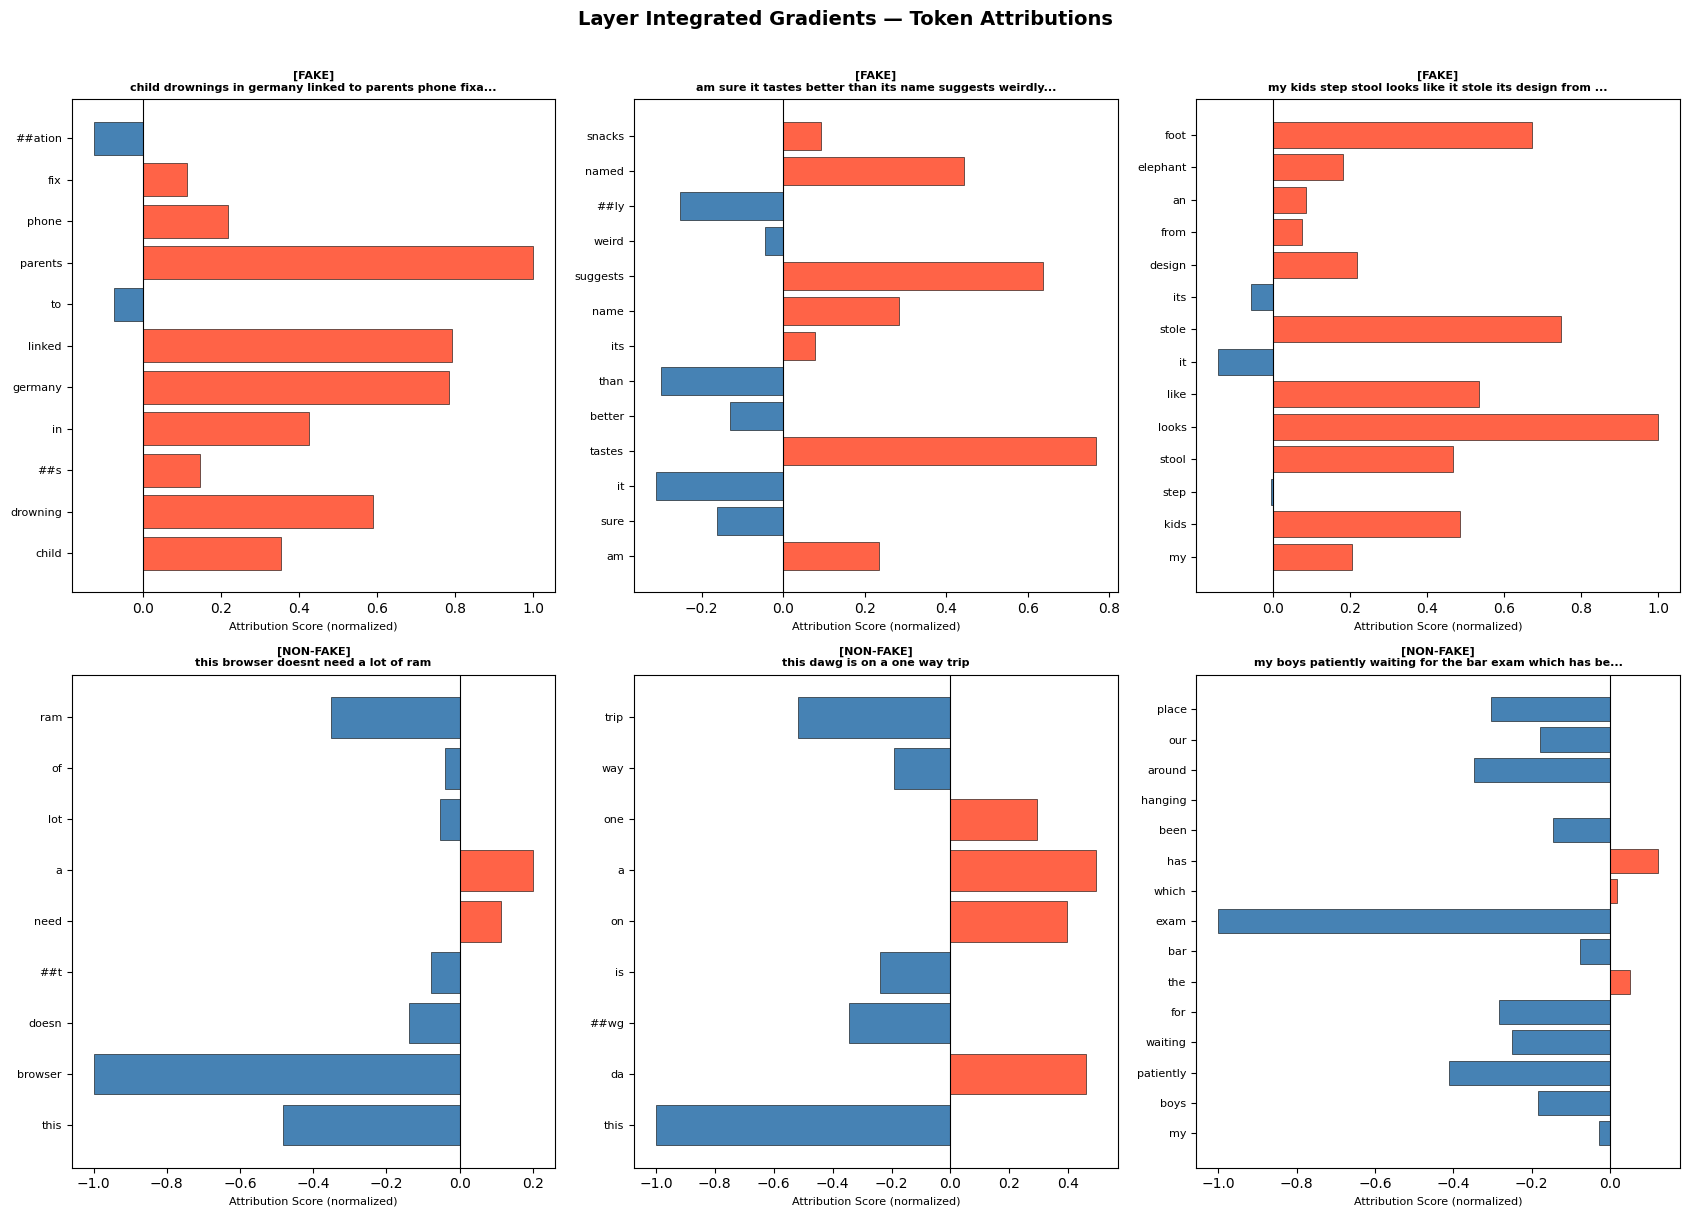

Saved: ig_attributions_new.png


In [16]:
# ── Visualization — Token Attribution Bar Charts ─────────────────────────────

def plot_attributions(result, ax, max_tokens=20):
    """Bar chart of per-token attribution scores."""
    special = {'[CLS]', '[SEP]', '[PAD]'}
    pairs   = [
        (tok, sc)
        for tok, sc in zip(result['tokens'], result['scores'])
        if tok not in special
    ][:max_tokens]

    toks, vals = zip(*pairs) if pairs else ([], [])
    colors = ['tomato' if v > 0 else 'steelblue' for v in vals]
    ax.barh(range(len(toks)), vals, color=colors, edgecolor='black', linewidth=0.4)
    ax.set_yticks(range(len(toks)))
    ax.set_yticklabels(toks, fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Attribution Score (normalized)', fontsize=8)
    short = result['text'][:55] + '...' if len(result['text']) > 55 else result['text']
    ax.set_title(f"[{result['label_name']}]\n{short}", fontsize=8, fontweight='bold')


fig, axes = plt.subplots(2, 3, figsize=(17, 12))
for ax, result in zip(axes.flatten(), all_results):
    plot_attributions(result, ax)

plt.suptitle('Layer Integrated Gradients — Token Attributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ig_attributions_new.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ig_attributions_new.png")

In [17]:
# ── Summary Table — Top-5 Tokens per Example ─────────────────────────────────
print("\n" + "=" * 70)
print(" TOP-5 TOKENS BY ATTRIBUTION — TASK 4 SUMMARY")
print("=" * 70)

for i, result in enumerate(all_results):
    print(f"\nExample {i+1} [{result['label_name']}]:")
    print(f"  Text : {result['text']}")
    print(f"  Target class : {result['label']} | Convergence delta : {result['delta']:.6f}")
    print(f"  {'Rank':<6} {'Token':<20} {'Attribution Score':>18}")
    print(f"  {'-'*46}")
    for rank, (tok, sc) in enumerate(result['top5'], 1):
        print(f"  {rank:<6} {tok:<20} {sc:>+18.4f}")

print("\n" + "=" * 70)


 TOP-5 TOKENS BY ATTRIBUTION — TASK 4 SUMMARY

Example 1 [FAKE]:
  Text : child drownings in germany linked to parents phone fixation
  Target class : 1 | Convergence delta : -0.004385
  Rank   Token                 Attribution Score
  ----------------------------------------------
  1      parents                         +1.0000
  2      linked                          +0.7924
  3      germany                         +0.7832
  4      drowning                        +0.5890
  5      in                              +0.4249

Example 2 [FAKE]:
  Text : am sure it tastes better than its name suggests weirdly named snacks
  Target class : 1 | Convergence delta : -0.005051
  Rank   Token                 Attribution Score
  ----------------------------------------------
  1      tastes                          +0.7662
  2      suggests                        +0.6378
  3      named                           +0.4433
  4      it                              -0.3121
  5      than                